# Analyse the output dcf peaks and plot results  
Based on the results from Douglas' dcfirr.py code  

Import functions, set matplotlib to display nicely:

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as pl
from ufo_functions import *
from scipy.stats import linregress
from matplotlib.ticker import *

Define approximate relation:

In [26]:
def line(x):
    return 1300.*(x/1.e7)**(-3./4.)

Set up plot:

log(t) = -0.732993538113 * log(nH) + 7.59215710849
t = 39098231.0275 * nH^-0.732993538113
log(t) = -0.888707752078 * log(nH) + 9.08079812726
t = 1204475934.7 * nH^-0.888707752078
log(t) = -0.73930780769 * log(nH) + 8.30849119703
t = 203465695.377 * nH^-0.73930780769
log(t) = -0.802235464571 * log(nH) + 8.34980015148
t = 223769118.724 * nH^-0.802235464571


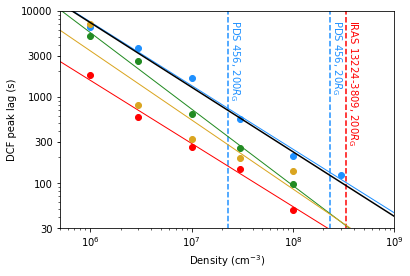

In [27]:
colours=['red','forestgreen','dodgerblue','goldenrod']


fig=pl.figure()

ax=pl.subplot(111)
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_major_locator(FixedLocator([10 ,30,100,300,1000,3000,10000]))
ax.yaxis.set_major_formatter(ScalarFormatter())
# ax.set_xlim(5.e5,2e9)
# ax.set_ylim(3.e1,1.e4)
ax.set_xlabel(r'$\mathrm{Density}\ (\mathrm{cm^{-3}})$')
ax.set_ylabel('DCF peak lag (s)')
ax.set_xlim(5.e5,1e9)
ax.set_ylim(3.e1,1.e4)


elements=['Si','S','Fe','Fe_xxvi']
run_settings=settings('halibut_settings.txt')


for i,element in enumerate(elements):
    stem=element+'_'
    lags=np.loadtxt(stem+'lag_values.txt')
    densities=[spex2cgs(x) for x in run_settings.densities][:len(lags)]
#     print lags
    
    # logs used for fitting line
    logx=np.log10(densities)
    logy=np.log10(lags)
    
    # use linregress to calculate the best fit
    m, c, r, p, std_err = linregress(logx[lags>88],logy[lags>88])
    print 'log(t) =',m,'* log(nH) +',c
    print 't =',10.**c,'*','nH^'+str(m)
    
    # dummy variable for line plot
    dummy_xs=np.logspace(min(logx)-1.,max(logx)+1.)
    new_ys=[10.**(m*np.log10(x)+c) for x in dummy_xs]

    # actually plot line, points
    pl.plot(dummy_xs,new_ys,color=colours[i],lw=1.)
    pl.plot(densities,lags,marker='o',color=colours[i],ls='none')

    
# Add IRAS, PDS values:

pl.plot(dummy_xs,line(dummy_xs),color='k')

pl.vlines([6.66e9/2.,6.66e8/2.],1.e1,1.e4,color='r',linestyles='dashed')
pl.text(6.66e8/2., 6000, r'IRAS 13224-3809, 200$R_\mathrm{G}$',rotation=270,color='r')


pl.vlines([4.6e8/2.,4.6e7/2.],1.e1,1.e4,color='dodgerblue',linestyles='dashed')
pl.text(4.6e8/2., 6000, r'PDS 456, 20$R_\mathrm{G}$',rotation=270,color='dodgerblue')
pl.text(4.6e7/2., 6000, r'PDS 456, 200$R_\mathrm{G}$',rotation=270,color='dodgerblue')
    
pl.show()
    
